# Multi-run latent exploration

Goal: load **all** ROOT runs in `Data/`, train one autoencoder on the combined dataset, then embed every event into latent space and color the UMAP by **run number** (and by **particle / energy** once those labels exist).

If two runs are physically different (different particle, different energy), they should occupy different regions of latent space even though the model has no labels. That's a free preview of what supervised training will show later.

**Plug-and-play for labels:** when you get the run→(particle, energy) mapping, save it as `Data/runs.csv` with columns `run,energy_GeV,particle`. This notebook auto-detects it and re-colors the plot.


In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from pathlib import Path
import re

def find_project_root(marker="Data", start=None):
    """Walk up from `start` (default: cwd) until we find a directory containing `marker`."""
    p = (start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).is_dir():
            return candidate
    raise FileNotFoundError(f"Could not find '{marker}' starting from {p}")

PROJECT_ROOT = find_project_root("Data")
print("project root:", PROJECT_ROOT)

DATA_DIR   = PROJECT_ROOT / "Data"
LABELS_CSV = DATA_DIR / "runs.csv"
WEIGHTS    = PROJECT_ROOT / "Rasmus" / "multi_run_ae.pt"  # cached trained weights
EVENTS_PER_RUN = 5000  # cap per run for speed; set to None to load all events per file
SEED = 0
torch.manual_seed(SEED); np.random.seed(SEED)


project root: /Users/prometheus/Documents/Python/ML_FoCal_FinalProject


## 1. Discover runs and labels

Scan `Data/` for `RunXXXX.root` files. If `runs.csv` is present, load the labels; otherwise fall back to using run numbers and print the expected format.


In [2]:
files = sorted(DATA_DIR.glob("Run*.root"))
print(f"found {len(files)} ROOT files:")
for f in files:
    print(f"  {f.name}")

def run_number(p):
    m = re.search(r"Run(\d+)", p.name)
    return int(m.group(1)) if m else -1

if LABELS_CSV.exists():
    import pandas as pd
    labels_df = pd.read_csv(LABELS_CSV)
    print(f"\nloaded labels from {LABELS_CSV.name}:")
    print(labels_df.to_string(index=False))
    rn_to_e = dict(zip(labels_df["run"], labels_df["energy_GeV"]))
    rn_to_p = dict(zip(labels_df["run"], labels_df["particle"]))
else:
    labels_df = None
    rn_to_e, rn_to_p = {}, {}
    print(f"\n[no labels yet] expected file: {LABELS_CSV}")
    print("format:")
    print("  run,energy_GeV,particle")
    print("  445,60,e")
    print("  446,80,e")
    print("  ...")
    print("\nproceeding with run number as the only label.")


found 17 ROOT files:
  Run0445.root
  Run0446.root
  Run0448.root
  Run0450.root
  Run0451.root
  Run0452.root
  Run0458.root
  Run0459.root
  Run577_EventMatch.root
  Run578_EventMatch.root
  Run579_EventMatch.root
  Run580_EventMatch.root
  Run603_EventMatch.root
  Run604_EventMatch.root
  Run605_EventMatch.root
  Run606_EventMatch.root
  Run607_EventMatch.root

loaded labels from runs.csv:
 run  energy_GeV particle  bias_V
 445         150        h       0
 446         200        h       0
 448         300        h       0
 450         100        h       0
 451          80        h       0
 452          60        h       0
 458         250        h       0
 459         350        h       0
 577          60        h      43
 578          60        h      43
 579          60        h      45
 580          60        h      45
 603          60        e      45
 604          60        e      45
 605          60        e      43
 606          60        e      43
 607          60        e 

## 2. Load events from every run

Stack `val0_list_0/1` into a `(N, 2, 64, 38)` tensor and a parallel `run_id` array of the same length. We cap `EVENTS_PER_RUN` for speed — bump it (or set to `None`) once you've confirmed the pipeline works.


In [3]:
val_chunks, run_ids = [], []
for f in files:
    rn = run_number(f)
    t = uproot.open(f)["data_tree"]
    n = t.num_entries
    take = n if EVENTS_PER_RUN is None else min(n, EVENTS_PER_RUN)

    a0 = t["val0_list_0"].array(library="np", entry_stop=take).reshape(-1, 64, 38)
    a1 = t["val0_list_1"].array(library="np", entry_stop=take).reshape(-1, 64, 38)
    val_chunks.append(np.stack([a0, a1], axis=1))
    run_ids.append(np.full(take, rn, dtype=np.int32))
    print(f"  Run{rn:04d}: {take:5d} / {n} events")

val0   = np.concatenate(val_chunks, axis=0)
run_id = np.concatenate(run_ids)
del val_chunks, run_ids

print(f"\ntotal: {val0.shape}  ({val0.nbytes / 1e9:.2f} GB)")
print("events per run:", dict(zip(*np.unique(run_id, return_counts=True))))


  Run0445:  5000 / 32969 events
  Run0446:  5000 / 33434 events
  Run0448:  5000 / 34683 events
  Run0450:  5000 / 32905 events
  Run0451:  5000 / 34088 events
  Run0452:  5000 / 37338 events
  Run0458:  5000 / 35122 events
  Run0459:  5000 / 33926 events
  Run0577:  5000 / 17621 events
  Run0578:  5000 / 22362 events
  Run0579:  5000 / 20390 events
  Run0580:  5000 / 19992 events
  Run0603:  3432 / 3432 events
  Run0604:  5000 / 10275 events
  Run0605:  5000 / 17010 events
  Run0606:  5000 / 18581 events
  Run0607:  5000 / 17227 events

total: (83432, 2, 64, 38)  (1.62 GB)
events per run: {np.int32(445): np.int64(5000), np.int32(446): np.int64(5000), np.int32(448): np.int64(5000), np.int32(450): np.int64(5000), np.int32(451): np.int64(5000), np.int32(452): np.int64(5000), np.int32(458): np.int64(5000), np.int32(459): np.int64(5000), np.int32(577): np.int64(5000), np.int32(578): np.int64(5000), np.int32(579): np.int64(5000), np.int32(580): np.int64(5000), np.int32(603): np.int64(3432),

## 3. Pedestal from quiet events (across all runs combined)

Same trick as the single-run notebook — compute per-channel mean/std from the bottom-50% events by total ADC, so loud events don't inflate the noise estimate.


In [4]:
event_sum = val0.sum(axis=(1, 2, 3)).astype(np.float64)
quiet_mask = event_sum < np.percentile(event_sum, 50)

mean_q = val0[quiet_mask].mean(axis=0).astype(np.float32)
std_q  = val0[quiet_mask].std(axis=0).astype(np.float32)
print(f"quiet events used: {quiet_mask.sum()} / {len(val0)}")
print(f"avg per-channel std: {std_q.mean():.2f}  range: {std_q.min():.2f} -> {std_q.max():.2f}")


quiet events used: 41714 / 83432
avg per-channel std: 20.93  range: 0.00 -> 359.86


## 4. Dataset + DataLoader

`run_id` rides along with each sample so we can color the latent plot later. The dataset returns `(x, run_id)` for every event.


In [5]:
class FoCalEvents(Dataset):
    def __init__(self, x, run_id, mean, std):
        self.x = ((x.astype(np.float32) - mean) / (std + 1e-3)).astype(np.float32)
        self.r = run_id.astype(np.int32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, i):
        return torch.from_numpy(self.x[i]), int(self.r[i])

ds = FoCalEvents(val0, run_id, mean_q, std_q)
n_train = int(0.8 * len(ds))
n_val   = len(ds) - n_train
train_ds, val_ds = random_split(ds, [n_train, n_val], generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False, num_workers=0)

xb, rb = next(iter(train_loader))
print("batch:", xb.shape, xb.dtype, "  runs in batch:", torch.unique(rb).tolist()[:10])
print("train:", len(train_ds), "val:", len(val_ds))


batch: torch.Size([256, 2, 64, 38]) torch.float32   runs in batch: [445, 446, 448, 450, 451, 452, 458, 459, 577, 578]
train: 66745 val: 16687


## 5. Convolutional autoencoder

Same architecture as `test.ipynb` — spatial latent `(16, 10, 16)`, L1 loss.


In [6]:
class ConvAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(2,  16, 3, padding=1),                 nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),       nn.ReLU(),
            nn.Conv2d(32, 16, 3, stride=2, padding=1),       nn.ReLU(),
        )
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(16, 32, 3, stride=2, padding=1, output_padding=(1, 0)), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=(1, 1)), nn.ReLU(),
            nn.Conv2d(16, 2, 3, padding=1),
        )

    def forward(self, x):
        z = self.enc(x)
        return self.dec(z), z

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
model = ConvAE().to(device)
print("device:", device, " params:", sum(p.numel() for p in model.parameters()))


device: mps  params: 19122


## 6. Train (or reuse cached weights)

Trains up to `MAX_EPOCHS` with **early stopping**: keep the best-val weights, stop if no improvement for `PATIENCE` epochs. `multi_run_ae.pt` caches the best weights — delete the file to force retrain.


In [7]:
import copy

MAX_EPOCHS = 100
PATIENCE   = 8       # stop if val loss hasn't improved for this many epochs
MIN_DELTA  = 1e-4    # treat smaller improvements as noise

if WEIGHTS.exists():
    model.load_state_dict(torch.load(WEIGHTS, map_location=device))
    print(f"loaded cached weights from {WEIGHTS}")
else:
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.L1Loss()
    history = {"train": [], "val": []}

    best_val = float("inf")
    best_epoch = -1
    best_state = copy.deepcopy(model.state_dict())
    bad_epochs = 0

    for epoch in range(MAX_EPOCHS):
        model.train()
        tr_loss = 0.0
        for x, _ in train_loader:
            x = x.to(device)
            x_hat, _ = model(x)
            loss = loss_fn(x_hat, x)
            opt.zero_grad(); loss.backward(); opt.step()
            tr_loss += loss.item() * x.size(0)
        tr_loss /= len(train_ds)

        model.eval()
        va_loss = 0.0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                x_hat, _ = model(x)
                va_loss += loss_fn(x_hat, x).item() * x.size(0)
        va_loss /= len(val_ds)

        history["train"].append(tr_loss); history["val"].append(va_loss)

        improved = va_loss < best_val - MIN_DELTA
        if improved:
            best_val   = va_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
            tag = " *"
        else:
            bad_epochs += 1
            tag = ""
        print(f"epoch {epoch+1:3d}/{MAX_EPOCHS}  train L1={tr_loss:.4f}  val L1={va_loss:.4f}  bad={bad_epochs}{tag}")

        if bad_epochs >= PATIENCE:
            print(f"\nearly stop at epoch {epoch+1}: no improvement for {PATIENCE} epochs")
            break

    # restore best weights and save
    model.load_state_dict(best_state)
    torch.save(best_state, WEIGHTS)
    print(f"\nbest val L1 = {best_val:.4f} at epoch {best_epoch+1}")
    print(f"saved {WEIGHTS}")

    plt.plot(history["train"], label="train")
    plt.plot(history["val"],   label="val")
    plt.axvline(best_epoch, color="k", linestyle="--", alpha=0.5, label=f"best @ {best_epoch+1}")
    plt.xlabel("epoch"); plt.ylabel("L1"); plt.legend(); plt.show()


loaded cached weights from /Users/prometheus/Documents/Python/ML_FoCal_FinalProject/Rasmus/multi_run_ae.pt


## 7. Encode every event

Run the encoder over **all** events (not just val), giving one latent vector per event. We keep run numbers aligned so we can color the projection by run.


In [8]:
full_loader = DataLoader(ds, batch_size=512, shuffle=False, num_workers=0)
model.eval()
all_lat, all_run = [], []
with torch.no_grad():
    for x, r in full_loader:
        x = x.to(device)
        _, z = model(x)
        all_lat.append(z.flatten(1).cpu().numpy())
        all_run.append(np.asarray(r))
all_lat = np.concatenate(all_lat, axis=0)
all_run = np.concatenate(all_run)
print("latent matrix:", all_lat.shape, "run id:", all_run.shape)


latent matrix: (83432, 2560) run id: (83432,)


## 8. PCA + UMAP colored by run and labels

If only one particle type is present, the particle panel is skipped (it would be one solid color). With all-hadron data, the interesting question is whether **energy** lines up with structure in the latent space — a clean gradient suggests the encoder learned shower energy as a feature even without supervision.


/Users/prometheus/Documents/Python/uni-env-3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


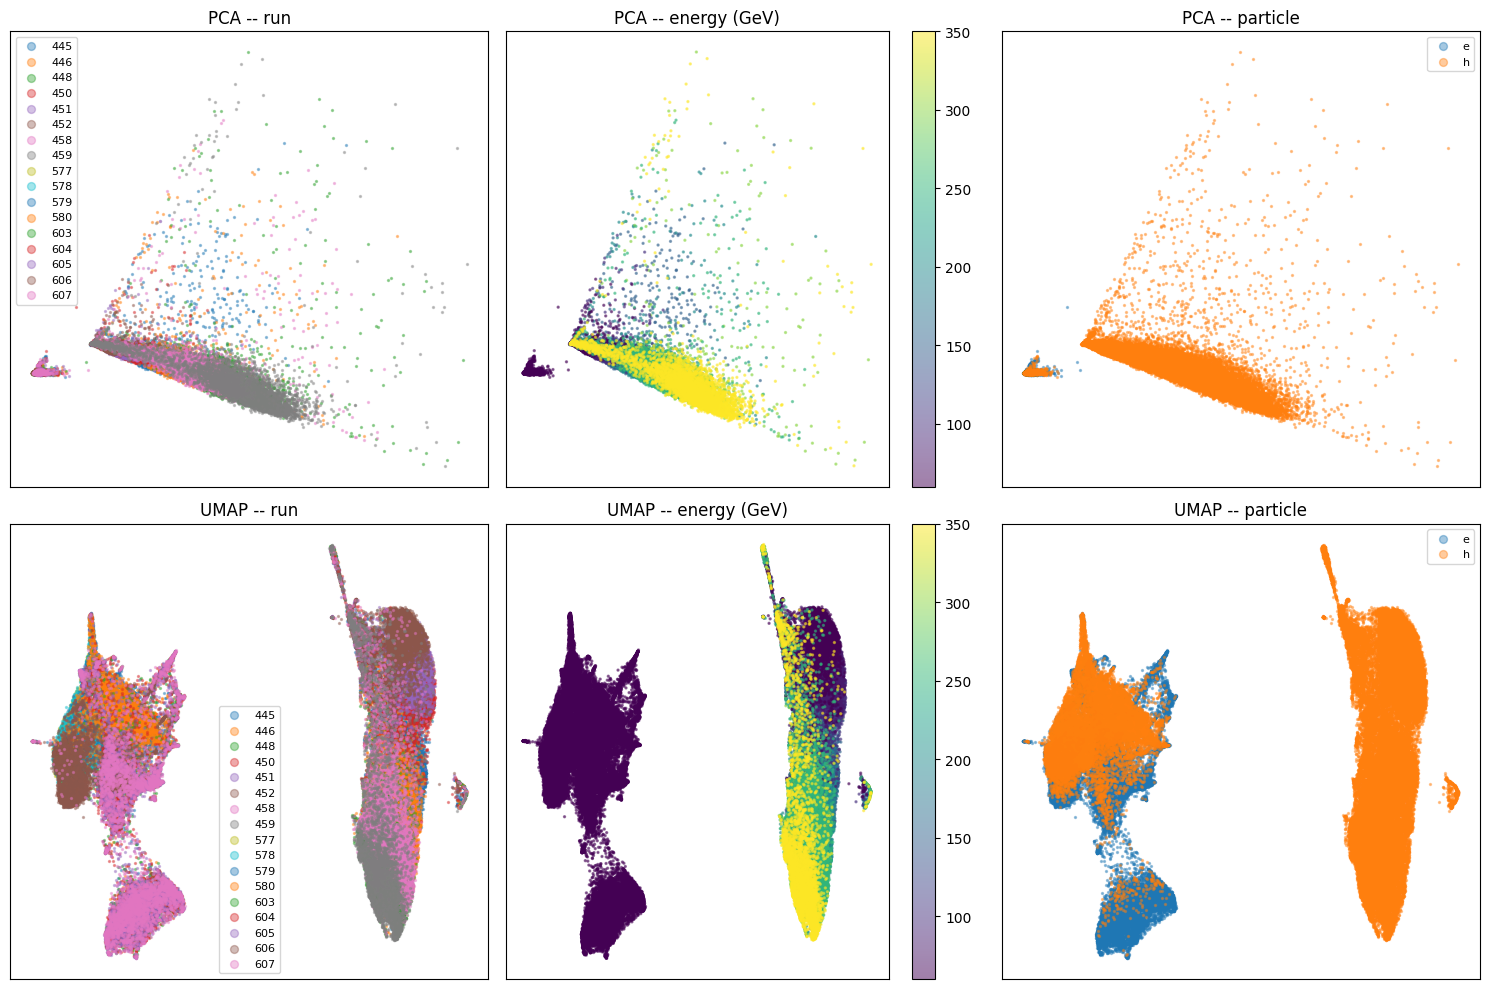

  Run0445: 150 GeV  h
  Run0446: 200 GeV  h
  Run0448: 300 GeV  h
  Run0450: 100 GeV  h
  Run0451: 80 GeV  h
  Run0452: 60 GeV  h
  Run0458: 250 GeV  h
  Run0459: 350 GeV  h
  Run0577: 60 GeV  h
  Run0578: 60 GeV  h
  Run0579: 60 GeV  h
  Run0580: 60 GeV  h
  Run0603: 60 GeV  e
  Run0604: 60 GeV  e
  Run0605: 60 GeV  e
  Run0606: 60 GeV  e
  Run0607: 60 GeV  e


In [9]:
from sklearn.decomposition import PCA
import umap

pca = PCA(n_components=2).fit_transform(all_lat)
ump = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=SEED).fit_transform(all_lat)

energy_arr   = np.array([rn_to_e.get(r, np.nan) for r in all_run])
particle_arr = np.array([rn_to_p.get(r, "?")   for r in all_run])
have_labels  = labels_df is not None
multi_particle = have_labels and len(set(particle_arr)) > 1

# How many label columns to show? run is always there; energy if available; particle only if >1 type
cols = ["run"]
if have_labels:
    cols.append("energy")
    if multi_particle:
        cols.append("particle")

fig, ax = plt.subplots(2, len(cols), figsize=(5 * len(cols), 10), squeeze=False)

def scatter(a, xy, c, title, cmap="tab10", categorical=True):
    if categorical:
        for u in np.unique(c):
            m = c == u
            a.scatter(xy[m, 0], xy[m, 1], s=2, alpha=0.4, label=str(u))
        a.legend(markerscale=4, fontsize=8, loc="best")
    else:
        sc = a.scatter(xy[:, 0], xy[:, 1], c=c, s=2, alpha=0.5, cmap=cmap)
        plt.colorbar(sc, ax=a)
    a.set_title(title); a.set_xticks([]); a.set_yticks([])

for ci, col in enumerate(cols):
    if col == "run":
        scatter(ax[0, ci], pca, all_run, "PCA -- run")
        scatter(ax[1, ci], ump, all_run, "UMAP -- run")
    elif col == "energy":
        scatter(ax[0, ci], pca, energy_arr, "PCA -- energy (GeV)", cmap="viridis", categorical=False)
        scatter(ax[1, ci], ump, energy_arr, "UMAP -- energy (GeV)", cmap="viridis", categorical=False)
    elif col == "particle":
        scatter(ax[0, ci], pca, particle_arr, "PCA -- particle")
        scatter(ax[1, ci], ump, particle_arr, "UMAP -- particle")
plt.tight_layout(); plt.show()

# also print the per-run energy mapping for reference
if have_labels:
    for rn in np.unique(all_run):
        print(f"  Run{rn:04d}: {rn_to_e.get(rn, '?')} GeV  {rn_to_p.get(rn, '?')}")


## 9. Per-run summary

Quick numerical view: per-run mean event_sum, mean number-of-hits, and how far each run's *centroid* sits from the global centroid in latent space. Big distances = runs the encoder finds easy to distinguish.


In [10]:
from numpy.linalg import norm

global_centroid = all_lat.mean(axis=0)
print(f"{'run':>5}  {'n':>6}  {'mean ADC':>10}  {'centroid dist':>14}")
for rn in np.unique(all_run):
    m = all_run == rn
    centroid = all_lat[m].mean(axis=0)
    print(f"  {rn:04d}  {m.sum():6d}  {val0[m].mean():10.2f}  {norm(centroid - global_centroid):14.3f}")


  run       n    mean ADC   centroid dist
  0445    5000      111.92         290.883
  0446    5000      116.01         375.280
  0448    5000      126.42         609.539
  0450    5000      106.99         205.125
  0451    5000      104.16         189.138
  0452    5000      101.56         191.392
  0458    5000      121.33         494.054
  0459    5000      129.80         708.688
  0577    5000      100.88         330.364
  0578    5000      100.90         330.091
  0579    5000      102.66         310.880
  0580    5000      102.68         310.543
  0603    3432      102.75         318.376
  0604    5000      102.77         318.243
  0605    5000      102.75         318.835
  0606    5000      101.14         333.264
  0607    5000      102.82         317.880
